In [1]:
import base64
import time
from io import BytesIO
from pathlib import Path
from typing import Optional

import ipywidgets as widgets
import markdown
import pypdfium2 as pdfium
from IPython.display import HTML, Image, display
from openai import OpenAI

MODEL_NAME = "unsloth/Qwen3.6-35B-A3B-GGUF:UD-Q4_K_XL"

client = OpenAI(base_url="http://127.0.0.1:8080/", api_key="api-keys-are-for-losers")

In [2]:
def collapsible(text, title="Reasoning"):
    html_content = markdown.markdown(text, extensions=["fenced_code", "codehilite"])

    styled_html = f"""
    <div style="
        background-color: #1e1e1e;
        color: #d4d4d4;
        padding: 12px;
        border-radius: 8px;
        font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
        line-height: 1.5;
    ">
        {html_content}
    </div>
    """

    out = widgets.Output()
    with out:
        display(HTML(styled_html))

    accordion = widgets.Accordion(children=[out])
    accordion.set_title(0, title)

    display(accordion)

In [3]:
def extract_from_file(
    file_path: str | Path, prompt: str, max_pages: Optional[int] = None
) -> str:
    t0_total = time.perf_counter()
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    content = [{"type": "text", "text": prompt}]

    if suffix == ".pdf":
        print(f"[*] Rasterizing '{file_path}' with pypdfium2...")
        t0_pdf = time.perf_counter()

        pdf = pdfium.PdfDocument(str(file_path))
        page_count = len(pdf)
        page_limit = page_count if max_pages is None else min(max_pages, page_count)

        try:
            for page_index in range(page_limit):
                page = pdf.get_page(page_index)
                try:
                    image = page.render(scale=1).to_pil()
                finally:
                    page.close()

                buffered = BytesIO()
                image.save(buffered, format="JPEG", quality=90)
                img_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

                content.append(
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"},
                    }
                )
        finally:
            pdf.close()

        t1_pdf = time.perf_counter()
        print(f"    -> PDF conversion took: {t1_pdf - t0_pdf:.2f} seconds.")
        print(f"    -> Prepared {page_limit} page image(s).")
    elif suffix in {".png", ".jpg", ".jpeg"}:
        print(f"[*] Loading image '{file_path}'...")
        t0_img = time.perf_counter()
        mime_type = "image/png" if suffix == ".png" else "image/jpeg"
        img_b64 = base64.b64encode(file_path.read_bytes()).decode("utf-8")
        content.append(
            {
                "type": "image_url",
                "image_url": {"url": f"data:{mime_type};base64,{img_b64}"},
            }
        )
        t1_img = time.perf_counter()
        print(f"    -> Image load took: {t1_img - t0_img:.2f} seconds.")
    else:
        raise ValueError(
            f"Unsupported file type: '{suffix}'. Expected .pdf, .png, .jpg, or .jpeg."
        )

    print("[*] Sending image(s) to local VLM...")
    print(f"    -> Prepared {len(content) - 1} image payload(s).")
    t0_llm = time.perf_counter()
    response = client.chat.completions.create(
        model=MODEL_NAME, messages=[{"role": "user", "content": content}]
    )
    t1_llm = time.perf_counter()
    print(f"    -> llama.cpp inference took: {t1_llm - t0_llm:.2f} seconds.")
    print(f"    -> Total latency: {t1_llm - t0_total:.2f} seconds.")

    usage = response.usage
    if usage:
        print("\n[*] Token Usage Metadata:")
        print(f"    -> Prompt Tokens:     {usage.prompt_tokens:,}")
        print(f"    -> Completion Tokens: {usage.completion_tokens:,}")
        print(f"    -> Total Tokens:      {usage.total_tokens:,}")
        print(
            f"    -> Speed:             {usage.completion_tokens / (t1_llm - t0_llm):.2f} output tokens/sec"
        )
    message = response.choices[0].message
    return message.reasoning_content, message.content

## Receipts


In [ ]:
Image(filename="./assets/receipts/naughty.jpg", width=512)

In [ ]:
prompt = """
Extract all text from this receipt. Return line items, total, tax, merchant, and date as JSON.
"""

reasoning, response = extract_from_file(
    file_path="./assets/receipts/naughty.jpg", prompt=prompt
)

In [ ]:
collapsible(reasoning)

In [ ]:
print(response)

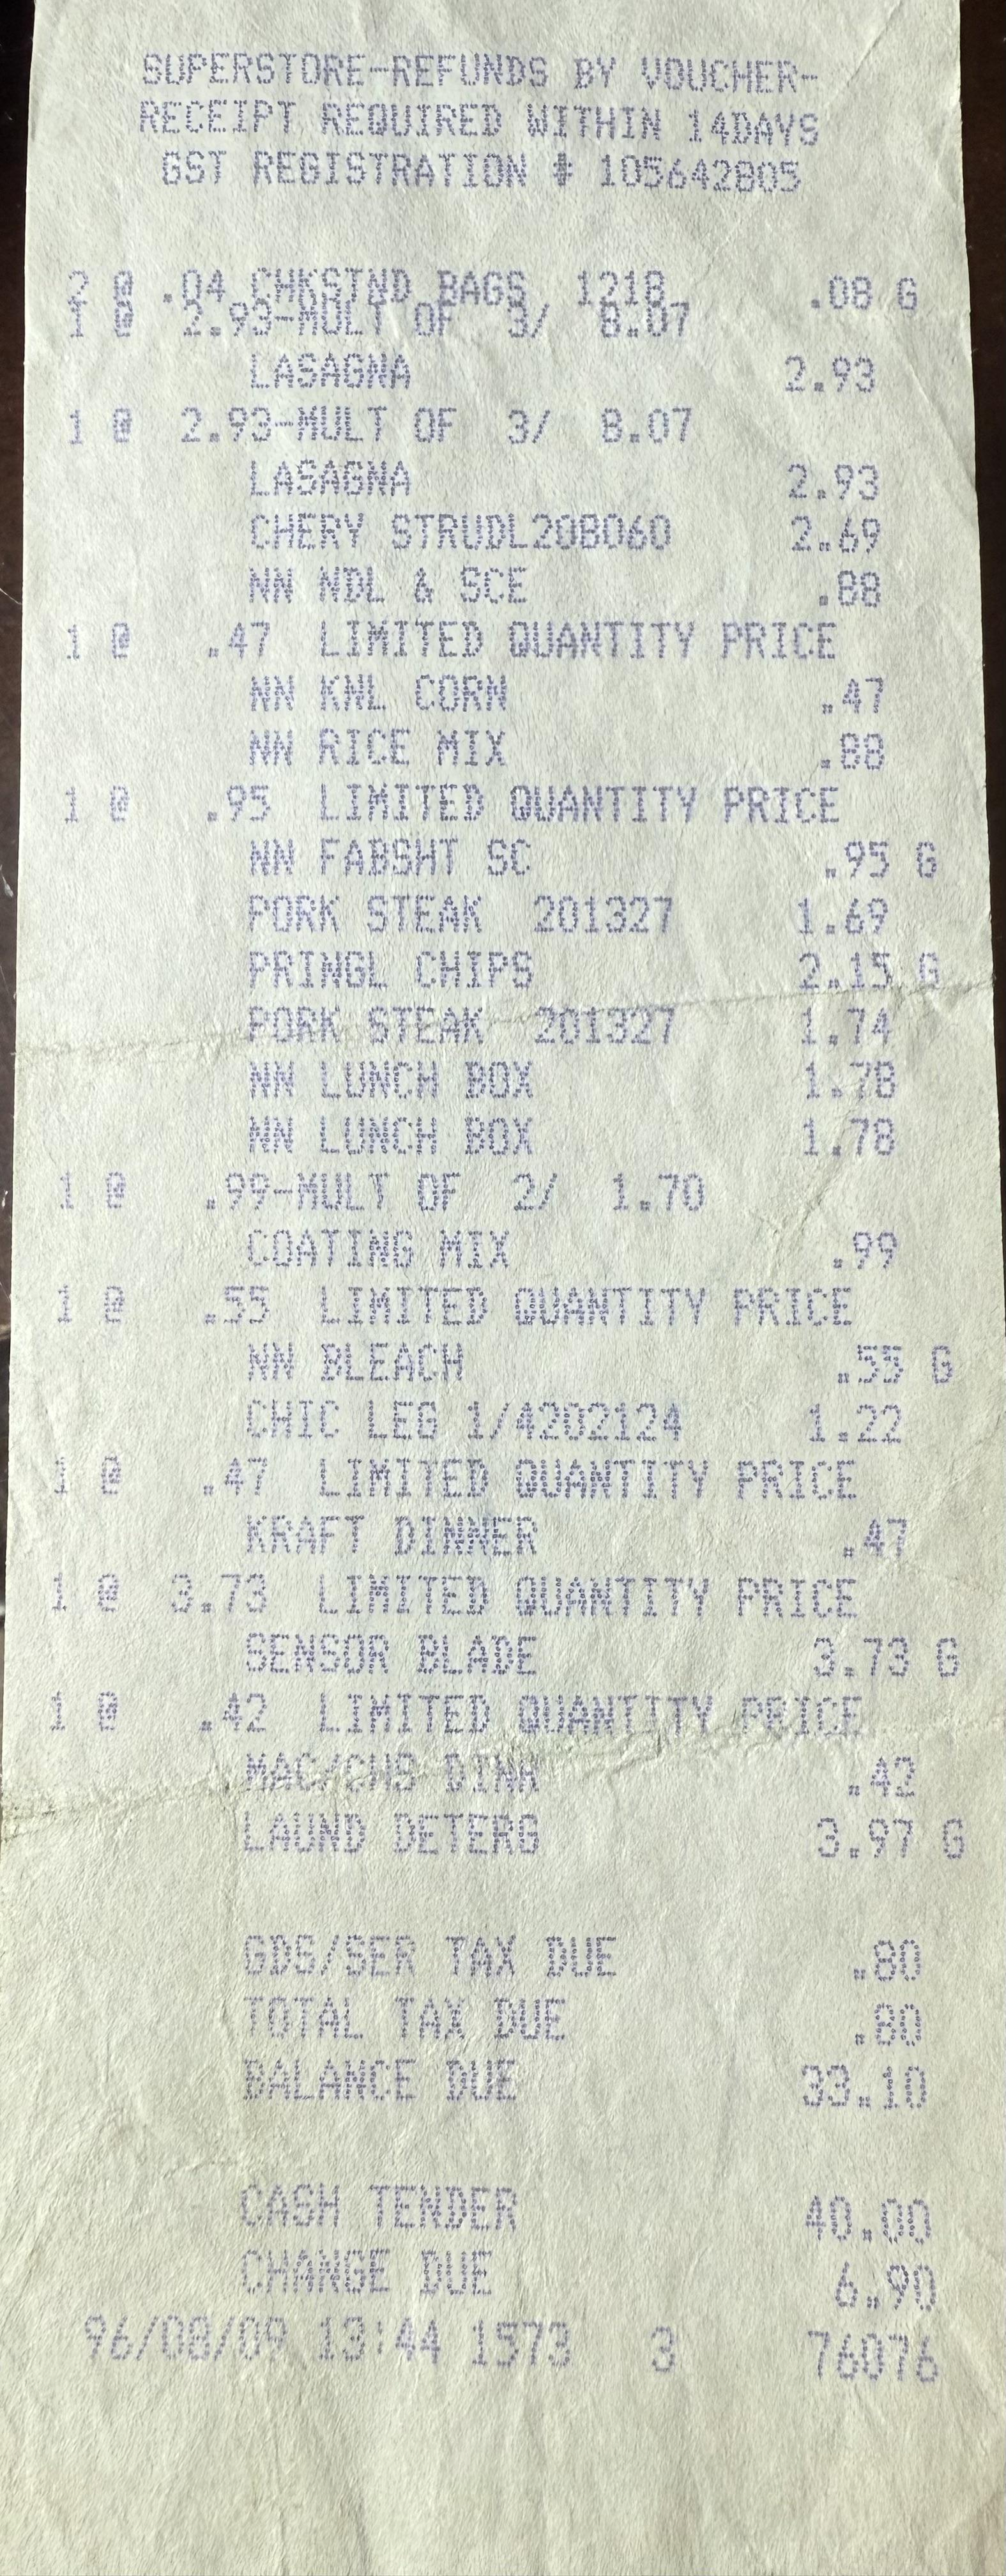

In [4]:
Image(filename="./assets/receipts/old.jpeg", width=512)

In [5]:
prompt = """
Extract all text from this receipt. Return line items, total, tax, merchant, and date as JSON.
"""

reasoning, response = extract_from_file(
    file_path="./assets/receipts/old.jpeg", prompt=prompt
)

[*] Loading image 'assets/receipts/old.jpeg'...
    -> Image load took: 0.00 seconds.
[*] Sending image(s) to local VLM...
    -> Prepared 1 image payload(s).
    -> llama.cpp inference took: 90.39 seconds.
    -> Total latency: 90.39 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     4,115
    -> Completion Tokens: 2,787
    -> Total Tokens:      6,902
    -> Speed:             30.83 output tokens/sec


In [7]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [8]:
print(response)

```json
{
    "line_items": [
        {
            "name": "CHKSTND BAGS",
            "price": 0.08,
            "quantity": 2
        },
        {
            "name": "LASAGNA",
            "price": 2.93,
            "quantity": 1
        },
        {
            "name": "LASAGNA",
            "price": 2.93,
            "quantity": 1
        },
        {
            "name": "CHERY STRUDL",
            "price": 2.69
        },
        {
            "name": "NN NDL & SCE",
            "price": 0.88
        },
        {
            "name": "NN KNL CORN",
            "price": 0.47,
            "quantity": 1
        },
        {
            "name": "NN RICE MIX",
            "price": 0.88
        },
        {
            "name": "NN FABSHT SC",
            "price": 0.95,
            "quantity": 1
        },
        {
            "name": "PORK STEAK",
            "price": 1.69
        },
        {
            "name": "PRINGL CHIPS",
            "price": 2.15
        },
        {
         

## Financial Docs


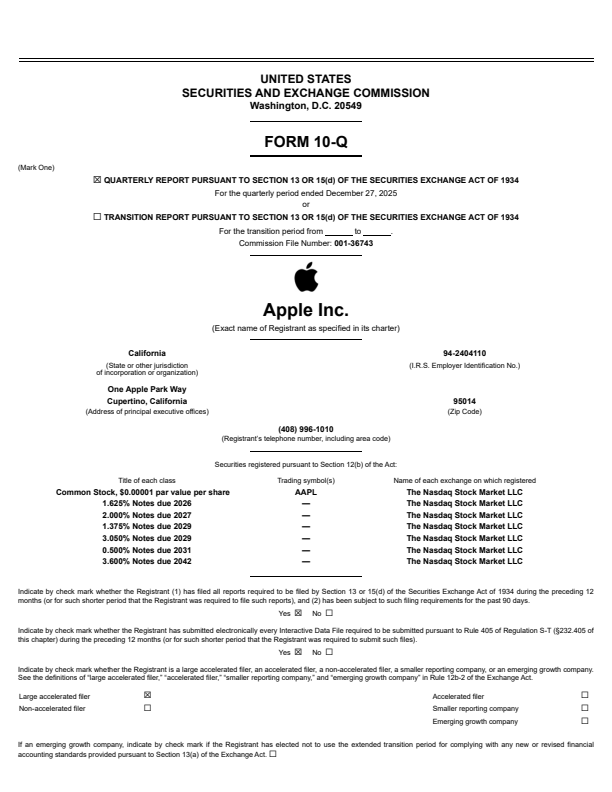

In [9]:
pdf = pdfium.PdfDocument(str("./assets/financial/apple-q1-2026.pdf"))
page = pdf.get_page(0)
image = page.render(scale=1).to_pil()
pdf.close()
image

In [10]:
prompt = """
Extract the specified data from the financial document. 
Return the company name, form type and company ticker as JSON.
"""

response = extract_from_file(
    file_path="./assets/financial/apple-q1-2026.pdf", prompt=prompt
)

[*] Rasterizing 'assets/financial/apple-q1-2026.pdf' with pypdfium2...
    -> PDF conversion took: 0.03 seconds.
    -> Prepared 8 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 8 image payload(s).
    -> llama.cpp inference took: 18.20 seconds.
    -> Total latency: 18.23 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     3,850
    -> Completion Tokens: 316
    -> Total Tokens:      4,166
    -> Speed:             17.36 output tokens/sec


In [12]:
reasoning, response = response

In [15]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [14]:
print(response)

```json
{
    "company_name": "Apple Inc.",
    "form_type": "10-Q",
    "company_ticker": "AAPL"
}
```


In [16]:
prompt = """
Extract the specified data from the financial document. 
Return the Note 2 - Revenue table as Markdown.
"""

response = extract_from_file(
    file_path="./assets/financial/apple-q1-2026.pdf", prompt=prompt
)

[*] Rasterizing 'assets/financial/apple-q1-2026.pdf' with pypdfium2...
    -> PDF conversion took: 0.04 seconds.
    -> Prepared 8 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 8 image payload(s).
    -> llama.cpp inference took: 42.66 seconds.
    -> Total latency: 42.70 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     3,848
    -> Completion Tokens: 1,295
    -> Total Tokens:      5,143
    -> Speed:             30.36 output tokens/sec


In [17]:
reasoning, response = response

In [18]:
print(response)

### Note 2 – Revenue

The following table shows disaggregated net sales, as well as the portion of total net sales that was previously deferred, for the three months ended December 27, 2025 and December 28, 2024 (in millions):

| | **Three Months Ended** | |
| :--- | :---: | :---: |
| | **December 27, 2025** | **December 28, 2024** |
| iPhone® | $ 85,269 | $ 69,138 |
| Mac® | 8,386 | 8,987 |
| iPad® | 8,595 | 8,088 |
| Wearables, Home and Accessories | 11,493 | 11,747 |
| Services | 30,013 | 26,340 |
| **Total net sales** | **$ 143,756** | **$ 124,300** |
| | | |
| Portion of total net sales that was included in deferred revenue as of the beginning of the period | $ 4,050 | $ 3,690 |


|                                                                                                    | **Three Months Ended** |                       |
| :------------------------------------------------------------------------------------------------- | :--------------------: | :-------------------: |
|                                                                                                    | **December 27, 2025**  | **December 28, 2024** |
| iPhone®                                                                                            |        $ 85,269        |       $ 69,138        |
| Mac®                                                                                               |         8,386          |         8,987         |
| iPad®                                                                                              |         8,595          |         8,088         |
| Wearables, Home and Accessories                                                                    |         11,493         |        11,747         |
| Services                                                                                           |         30,013         |        26,340         |
| **Total net sales**                                                                                |     **$ 143,756**      |     **$ 124,300**     |
|                                                                                                    |                        |                       |
| Portion of total net sales that was included in deferred revenue as of the beginning of the period |        $ 4,050         |        $ 3,690        |


In [19]:
prompt = """
Extract the specified data from the financial document. 
Return the condensed consolidated balance sheets table as Markdown.
"""

response = extract_from_file(
    file_path="./assets/financial/nvidia-q3-2025-press-release.pdf", prompt=prompt
)

[*] Rasterizing 'assets/financial/nvidia-q3-2025-press-release.pdf' with pypdfium2...
    -> PDF conversion took: 0.06 seconds.
    -> Prepared 10 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 10 image payload(s).
    -> llama.cpp inference took: 48.29 seconds.
    -> Total latency: 48.36 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     4,991
    -> Completion Tokens: 1,392
    -> Total Tokens:      6,383
    -> Speed:             28.82 output tokens/sec


In [20]:
reasoning, response = response

In [21]:
print(response)

```markdown
| | October 26, 2025 | January 26, 2025 |
| :--- | :--- | :--- |
| **ASSETS** | | |
| **Current assets:** | | |
| Cash, cash equivalents and marketable securities | $ 60,608 | $ 43,210 |
| Accounts receivable, net | 33,391 | 23,065 |
| Inventories | 19,784 | 10,080 |
| Prepaid expenses and other current assets | 2,709 | 3,771 |
| Total current assets | 116,492 | 80,126 |
| Property and equipment, net | 9,780 | 6,283 |
| Operating lease assets | 2,281 | 1,793 |
| Goodwill | 6,261 | 5,188 |
| Intangible assets, net | 936 | 807 |
| Deferred income tax assets | 13,674 | 10,979 |
| Other assets | 11,724 | 6,425 |
| Total assets | $ 161,148 | $ 111,601 |
| **LIABILITIES AND SHAREHOLDERS' EQUITY** | | |
| **Current liabilities:** | | |
| Accounts payable | $ 8,624 | $ 6,310 |
| Accrued and other current liabilities | 16,452 | 11,737 |
| Short-term debt | 999 | - |
| Total current liabilities | 26,075 | 18,047 |
| Long-term debt | 7,468 | 8,463 |
| Long-term operating lease liabili

|                                                  | October 26, 2025 | January 26, 2025 |
| :----------------------------------------------- | :--------------- | :--------------- |
| **ASSETS**                                       |                  |                  |
| **Current assets:**                              |                  |                  |
| Cash, cash equivalents and marketable securities | $ 60,608         | $ 43,210         |
| Accounts receivable, net                         | 33,391           | 23,065           |
| Inventories                                      | 19,784           | 10,080           |
| Prepaid expenses and other current assets        | 2,709            | 3,771            |
| Total current assets                             | 116,492          | 80,126           |
| Property and equipment, net                      | 9,780            | 6,283            |
| Operating lease assets                           | 2,281            | 1,793            |
| Goodwill                                         | 6,261            | 5,188            |
| Intangible assets, net                           | 936              | 807              |
| Deferred income tax assets                       | 13,674           | 10,979           |
| Other assets                                     | 11,724           | 6,425            |
| Total assets                                     | $ 161,148        | $ 111,601        |
| **LIABILITIES AND SHAREHOLDERS' EQUITY**         |                  |                  |
| **Current liabilities:**                         |                  |                  |
| Accounts payable                                 | $ 8,624          | $ 6,310          |
| Accrued and other current liabilities            | 16,452           | 11,737           |
| Short-term debt                                  | 999              | -                |
| Total current liabilities                        | 26,075           | 18,047           |
| Long-term debt                                   | 7,468            | 8,463            |
| Long-term operating lease liabilities            | 2,014            | 1,519            |
| Other long-term liabilities                      | 6,694            | 4,245            |
| Total liabilities                                | 42,251           | 32,274           |
| Shareholders' equity                             | 118,897          | 79,327           |
| Total liabilities and shareholders' equity       | $ 161,148        | $ 111,601        |


In [ ]:
prompt = """
Extract the specified data from the research paper. 
From the SSD temperature sweep table, extract the value at 
Teval 1.2 and Ttrain 0.9.
"""

# 55.6
response = extract_from_file(
    file_path="./assets/papers/simple-self-distillation-excerpt.pdf", prompt=prompt
)

In [ ]:
print(response)

In [ ]:
prompt = """
Extract the specified data from the research paper. 
From the SSD temperature sweep table, extract the value at 
Teval 1.2 and Ttrain 0.9.
"""

# 55.6
response = extract_from_file(file_path="./assets/papers/single-page.jpg", prompt=prompt)

In [ ]:
print(response)